<a href="https://colab.research.google.com/github/ayeshasaleem13/AI/blob/main/pdc_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get install openjdk-8-jdk -y

# Download Spark (working archive link)
!wget https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz

# Extract Spark
!tar -xvf spark-3.5.1-bin-hadoop3.tgz

# Install findspark
!pip install -q findspark

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common librsvg2-common libxcomposite1 libxt-dev
  libxtst6 libxxf86dga1 openjdk-8-jdk-headless openjdk-8-jre
  openjdk-8-jre-headless session-migration x11-utils
Suggested packages:
  gvfs libxt-doc openjdk-8-demo openjdk-8-source visualvm libnss-mdns
  fonts-nanum fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  fonts-wqy-zenhei fonts-indic mesa-utils
The following NEW packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 

In [ ]:
import os
import findspark

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

findspark.init()

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Spark Project") \
    .getOrCreate()

print("✅ Spark Started Successfully")

✅ Spark Started Successfully


In [ ]:
data = [("A", 1), ("B", 2), ("C", 3)]

df = spark.createDataFrame(data, ["Name", "Value"])
df.show()

+----+-----+
|Name|Value|
+----+-----+
|   A|    1|
|   B|    2|
|   C|    3|
+----+-----+



In [ ]:
from pyspark.sql import Row

data = [
    Row(id=1, product="Laptop", category="Electronics", price=1000, quantity=2),
    Row(id=2, product="Phone", category="Electronics", price=500, quantity=5),
    Row(id=3, product="Shoes", category="Fashion", price=80, quantity=10),
    Row(id=4, product="Watch", category="Fashion", price=150, quantity=3),
    Row(id=5, product="TV", category="Electronics", price=800, quantity=1),
]

df = spark.createDataFrame(data)
df.show()

+---+-------+-----------+-----+--------+
| id|product|   category|price|quantity|
+---+-------+-----------+-----+--------+
|  1| Laptop|Electronics| 1000|       2|
|  2|  Phone|Electronics|  500|       5|
|  3|  Shoes|    Fashion|   80|      10|
|  4|  Watch|    Fashion|  150|       3|
|  5|     TV|Electronics|  800|       1|
+---+-------+-----------+-----+--------+



In [ ]:
import random
from pyspark.sql import Row

products = ["Laptop", "Phone", "Shoes", "Watch", "TV", "Headphones"]
categories = ["Electronics", "Fashion"]

data = []

for i in range(1000):
    data.append(
        Row(
            id=i,
            product=random.choice(products),
            category=random.choice(categories),
            price=random.choice([random.randint(50, 2000), None]),  # introduce NULL
            quantity=random.randint(1, 10)
        )
    )

df = spark.createDataFrame(data)
df.show()

NameError: name 'spark' is not defined

In [ ]:
df_clean = df.dropna()
df_clean = df_clean.dropDuplicates()

from pyspark.sql.functions import col, when

df_clean = df_clean.withColumn(
    "total_price", col("price") * col("quantity")
)

df_clean = df_clean.withColumn(
    "discount",
    when(col("total_price") > 1000, 0.1).otherwise(0)
)

df_clean = df_clean.withColumn(
    "final_price",
    col("total_price") - (col("total_price") * col("discount"))
)

df_clean.show()

In [ ]:
df_clean = df.dropna()
df_clean.show()

+---+----------+-----------+-----+--------+
| id|   product|   category|price|quantity|
+---+----------+-----------+-----+--------+
|  1|     Shoes|    Fashion|  730|       2|
|  2|        TV|    Fashion|  215|       4|
|  3|    Laptop|    Fashion|  780|       6|
|  4|        TV|Electronics|  730|       2|
|  5|     Watch|Electronics| 1596|       6|
|  9|     Watch|Electronics|  685|      10|
| 10|Headphones|Electronics|  556|      10|
| 11|Headphones|    Fashion| 1412|       5|
| 15|    Laptop|    Fashion| 1042|       4|
| 19|     Shoes|Electronics| 1613|       9|
| 21|        TV|    Fashion|  502|       2|
| 22|     Shoes|    Fashion| 1303|       9|
| 23|Headphones|Electronics| 1438|       2|
| 24|     Watch|    Fashion|  555|       9|
| 25|Headphones|Electronics|  669|       8|
| 27|        TV|    Fashion| 1224|       3|
| 28|        TV|Electronics|  927|       8|
| 31|     Phone|    Fashion| 1877|      10|
| 32|     Phone|    Fashion|  789|       1|
| 33|     Shoes|Electronics| 165

In [ ]:
df_clean = df_clean.dropDuplicates()

In [ ]:
from pyspark.sql.functions import col

df_clean = df_clean.withColumn(
    "total_price", col("price") * col("quantity")
)

In [ ]:
from pyspark.sql.functions import when

df_clean = df_clean.withColumn(
    "discount",
    when(col("total_price") > 1000, 0.1).otherwise(0)
)

In [ ]:
df_clean = df_clean.withColumn(
    "final_price",
    col("total_price") - (col("total_price") * col("discount"))
)

df_clean.show()

+---+----------+-----------+-----+--------+-----------+--------+-----------+
| id|   product|   category|price|quantity|total_price|discount|final_price|
+---+----------+-----------+-----+--------+-----------+--------+-----------+
|159|     Shoes|    Fashion|  203|       3|        609|     0.0|      609.0|
|242|        TV|Electronics| 1990|       3|       5970|     0.1|     5373.0|
|140|     Shoes|    Fashion| 1732|       7|      12124|     0.1|    10911.6|
|191|Headphones|    Fashion| 1839|       7|      12873|     0.1|    11585.7|
|373|        TV|Electronics| 1568|       7|      10976|     0.1|     9878.4|
| 51|Headphones|    Fashion| 1953|       6|      11718|     0.1|    10546.2|
|276|    Laptop|    Fashion|   96|       2|        192|     0.0|      192.0|
|299|     Shoes|Electronics|  823|       3|       2469|     0.1|     2222.1|
|456|        TV|    Fashion|  345|       5|       1725|     0.1|     1552.5|
|471|     Phone|    Fashion| 1617|       2|       3234|     0.1|     2910.6|

In [ ]:
high_sales = df_clean.filter(col("final_price") > 500)
high_sales.show()

+---+----------+-----------+-----+--------+-----------+--------+-----------+
| id|   product|   category|price|quantity|total_price|discount|final_price|
+---+----------+-----------+-----+--------+-----------+--------+-----------+
|159|     Shoes|    Fashion|  203|       3|        609|     0.0|      609.0|
|242|        TV|Electronics| 1990|       3|       5970|     0.1|     5373.0|
|140|     Shoes|    Fashion| 1732|       7|      12124|     0.1|    10911.6|
|191|Headphones|    Fashion| 1839|       7|      12873|     0.1|    11585.7|
|373|        TV|Electronics| 1568|       7|      10976|     0.1|     9878.4|
| 51|Headphones|    Fashion| 1953|       6|      11718|     0.1|    10546.2|
|299|     Shoes|Electronics|  823|       3|       2469|     0.1|     2222.1|
|456|        TV|    Fashion|  345|       5|       1725|     0.1|     1552.5|
|471|     Phone|    Fashion| 1617|       2|       3234|     0.1|     2910.6|
|470|     Phone|Electronics| 1866|      10|      18660|     0.1|    16794.0|

In [ ]:
category_sales = df_clean.groupBy("category") \
    .sum("final_price")

category_sales.show()

+-----------+------------------+
|   category|  sum(final_price)|
+-----------+------------------+
|    Fashion|1241364.7999999993|
|Electronics|1374224.0000000002|
+-----------+------------------+



In [ ]:
# ===============================
# PRODUCT-WISE SALES + REDUCE + SORT + LOAD
# ===============================

from pyspark.sql.functions import col

# 🔹 Product-wise sales (Aggregation)
product_sales = df_clean.groupBy("product") \
    .sum("final_price")

print("=== Product-wise Sales ===")
product_sales.show()

# 🔹 Reduce (Total Revenue using RDD)
rdd = df_clean.rdd

total_revenue = rdd.map(lambda x: x.final_price) \
                   .reduce(lambda x, y: x + y)

print("=== Total Revenue ===")
print(total_revenue)

# 🔹 Sorting (Top selling products)
top_products = product_sales.orderBy("sum(final_price)", ascending=False)

print("=== Top Selling Products ===")
top_products.show()

# 🔹 Load (Save cleaned data)
df_clean.write.mode("overwrite").csv("cleaned_output")

print("✅ Data successfully saved to 'cleaned_output'")

=== Product-wise Sales ===
+----------+------------------+
|   product|  sum(final_price)|
+----------+------------------+
|        TV|          383219.4|
|     Phone| 498134.0999999999|
|    Laptop|380572.80000000005|
|     Shoes|          393054.2|
|     Watch|483018.69999999995|
|Headphones|477589.59999999986|
+----------+------------------+

=== Total Revenue ===
2615588.8000000017
=== Top Selling Products ===
+----------+------------------+
|   product|  sum(final_price)|
+----------+------------------+
|     Phone| 498134.0999999999|
|     Watch|483018.69999999995|
|Headphones|477589.59999999986|
|     Shoes|          393054.2|
|        TV|          383219.4|
|    Laptop|380572.80000000005|
+----------+------------------+

✅ Data successfully saved to 'cleaned_output'


In [ ]:
df.createOrReplaceTempView("products")
print("Table 'products' created successfully")

Table 'products' created successfully


In [ ]:
df_clean.createOrReplaceTempView("sales")

In [ ]:
total_sales_sql = spark.sql("""
SELECT SUM(final_price) AS total_revenue
FROM sales
""")

total_sales_sql.show()


+------------------+
|     total_revenue|
+------------------+
|2615588.8000000017|
+------------------+



In [ ]:
category_sql = spark.sql("""
SELECT category, SUM(final_price) AS revenue
FROM sales
GROUP BY category
ORDER BY revenue DESC
""")

category_sql.show()


+-----------+------------------+
|   category|           revenue|
+-----------+------------------+
|Electronics|1374224.0000000002|
|    Fashion|1241364.7999999993|
+-----------+------------------+



In [ ]:
product_sql = spark.sql("""
SELECT product, SUM(final_price) AS total_sales
FROM sales
GROUP BY product
ORDER BY total_sales DESC
""")

product_sql.show()


+----------+------------------+
|   product|       total_sales|
+----------+------------------+
|     Phone| 498134.0999999999|
|     Watch|483018.69999999995|
|Headphones|477589.59999999986|
|     Shoes|          393054.2|
|        TV|          383219.4|
|    Laptop|380572.80000000005|
+----------+------------------+



In [ ]:
top_transactions = spark.sql("""
SELECT * FROM sales
ORDER BY final_price DESC
LIMIT 5
""")

top_transactions.show()


+---+-------+-----------+-----+--------+-----------+--------+-----------+
| id|product|   category|price|quantity|total_price|discount|final_price|
+---+-------+-----------+-----+--------+-----------+--------+-----------+
|132|  Phone|Electronics| 1902|      10|      19020|     0.1|    17118.0|
|845|  Phone|Electronics| 1885|      10|      18850|     0.1|    16965.0|
| 31|  Phone|    Fashion| 1877|      10|      18770|     0.1|    16893.0|
|470|  Phone|Electronics| 1866|      10|      18660|     0.1|    16794.0|
|171|     TV|    Fashion| 1999|       9|      17991|     0.1|    16191.9|
+---+-------+-----------+-----+--------+-----------+--------+-----------+



In [ ]:

avg_sales = spark.sql("""
SELECT category, AVG(final_price) AS avg_sales
FROM sales
GROUP BY category
""")

avg_sales.show()


+-----------+-----------------+
|   category|        avg_sales|
+-----------+-----------------+
|    Fashion|5129.606611570245|
|Electronics|5166.255639097745|
+-----------+-----------------+



In [ ]:
python_data = df_clean.select("price", "quantity").collect()

In [ ]:
import time

start = time.time()

total_python = 0
for row in python_data:
    total_python += row["price"] * row["quantity"]

python_time = time.time() - start

print("Python Total:", total_python)
print("Python Time:", python_time)


Python Total: 2902352
Python Time: 0.001262664794921875


In [ ]:
start = time.time()

total_spark = df_clean.rdd.map(lambda x: x.final_price) \
                          .reduce(lambda x, y: x + y)

spark_time = time.time() - start

print("Spark Total:", total_spark)
print("Spark Time:", spark_time)

Spark Total: 2615588.8000000017
Spark Time: 0.22841405868530273


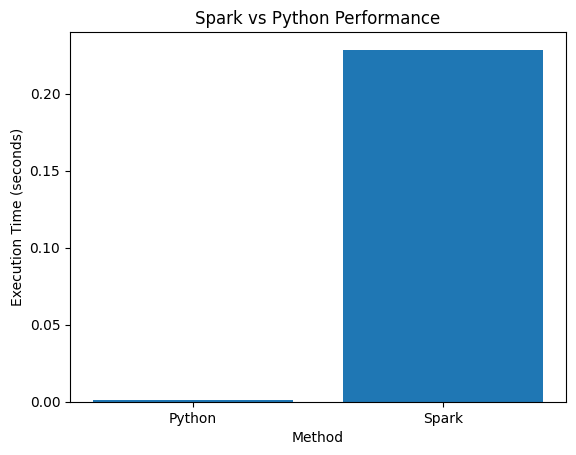

In [ ]:
import matplotlib.pyplot as plt

methods = ["Python", "Spark"]
times = [python_time, spark_time]

plt.figure()
plt.bar(methods, times)
plt.title("Spark vs Python Performance")
plt.ylabel("Execution Time (seconds)")
plt.xlabel("Method")
plt.show()